# Sustainabilty models

In [1]:
# ----------------------------
# IMPORTS + CONFIG
# ----------------------------

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import plot_tree

# ============================================================
# SETTINGS
# ============================================================

pd.set_option(
    'display.float_format',
    '{:.2f}'.format
)


PROJECT_ROOT = Path.cwd().parent

CONFIG = {
    "features_dir": PROJECT_ROOT / "01_data" / "03_features",
    "input_file": "llm_sustainability_strict_v1-2-0_dataframe.csv",
    "output_file": "llm_sustainability_strict_v1-3-0_dataframe.csv",
    "embeddings_file": "llm_sustainability_strict_v1-1-0_embeddings.npy",
    "random_state": 42,
}

INPUT_PATH = CONFIG["features_dir"] / CONFIG["input_file"]
OUTPUT_PATH = CONFIG["features_dir"] / CONFIG["output_file"]
EMBEDDINGS_PATH = CONFIG["features_dir"] / CONFIG["embeddings_file"]

print("INPUT_PATH:", INPUT_PATH)
print("OUTPUT_PATH:", OUTPUT_PATH)
print("EMBEDDINGS_PATH:", EMBEDDINGS_PATH)

INPUT_PATH: c:\Users\heike\Desktop\Stackfuel\Portfolio\llm-sustainability-analysis\01_data\03_features\llm_sustainability_strict_v1-2-0_dataframe.csv
OUTPUT_PATH: c:\Users\heike\Desktop\Stackfuel\Portfolio\llm-sustainability-analysis\01_data\03_features\llm_sustainability_strict_v1-3-0_dataframe.csv
EMBEDDINGS_PATH: c:\Users\heike\Desktop\Stackfuel\Portfolio\llm-sustainability-analysis\01_data\03_features\llm_sustainability_strict_v1-1-0_embeddings.npy


c:\Users\heike\Desktop\Stackfuel\Portfolio\llm-sustainability-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ----------------------------
# IO HELPERS
# ----------------------------

def load_csv(INPUT_PATH):
    with Path(INPUT_PATH).open("r", encoding="utf-8") as file:
        return pd.read_csv(file)

def load_emb(EMBEDDINGS_PATH):
    with Path(EMBEDDINGS_PATH).open("rb") as file:
        return np.load(file)

def save_csv(df, OUTPUT_PATH):
    path = Path(OUTPUT_PATH)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)


In [3]:
# ----------------------------
# LOAD DATA
# ----------------------------

embeddings = load_emb(EMBEDDINGS_PATH)

df = load_csv(INPUT_PATH)

print("Input path:", INPUT_PATH)
print("Exists:", INPUT_PATH.exists())
print("Shape:", df.shape)
print("Embeddings shape:", embeddings.shape)

df.head()

Input path: c:\Users\heike\Desktop\Stackfuel\Portfolio\llm-sustainability-analysis\01_data\03_features\llm_sustainability_strict_v1-2-0_dataframe.csv
Exists: True
Shape: (46429, 36)
Embeddings shape: (46429, 384)


,conversation_id,first_prompt,first_response,first_prompt_tokens,first_response_tokens,total_turns,interaction_rounds,total_user_prompts,followup_prompts,needs_follow_up,...,topic_label,topic_cat,embedding_novelty,target_cost,log_target_cost,target_no_refusal,target_no_capability,target_needs_clarification,log_first_prompt_tokens,log_question_count
0,QWJhYvA,Summarize the main ideas of Jeff Walker's Prod...,<div><p>Here are the main ideas of Jeff Walker...,34,304,12,6.00,6,5,1,...,0_chatgpt_write_use_like_want,general,0.55,304,5.72,1,1,0,3.56,0.00
1,i6IyJda,How to tell if a customer segment is well segm...,"<div class=""markdown prose w-full break-words ...",17,113,2,1.00,1,0,0,...,-1_like_data_use_write_make,noise,0.78,113,4.74,1,1,0,2.89,0.69
2,A5AbcES,"In Java, I want to replace string like ""This i...","<div class=""markdown prose w-full break-words ...",62,1468,2,1.00,1,0,0,...,-1_like_data_use_write_make,noise,0.96,1468,7.29,1,1,0,4.14,0.69
3,hRPPgZT,Metaphorical language is also used to describe...,<div><p>Metaphorical language has been summone...,90,132,22,11.00,11,10,1,...,-1_like_data_use_write_make,noise,0.73,132,4.89,1,1,0,4.51,0.00
4,KXxu9my,The following is the job of the hosting servic...,"<div class=""markdown prose w-full break-words ...",507,1014,10,5.00,5,4,1,...,-1_like_data_use_write_make,noise,0.59,1014,6.92,1,1,0,6.23,0.00


In [4]:
df.columns

Index(['conversation_id', 'first_prompt', 'first_response',
       'first_prompt_tokens', 'first_response_tokens', 'total_turns',
       'interaction_rounds', 'total_user_prompts', 'followup_prompts',
       'needs_follow_up', 'total_user_tokens', 'total_assistant_tokens',
       'total_tokens', 'log_total_tokens', 'has_role_instruction',
       'has_audience_or_level_instruction', 'has_format_instruction',
       'question_count', 'prompt_style', 'task_type',
       'orthographic_error_rate', 'is_valid_prompt', 'clean_response',
       'clean_prompt', 'topic', 'topic_prob', 'topic_label', 'topic_cat',
       'embedding_novelty', 'target_cost', 'log_target_cost',
       'target_no_refusal', 'target_no_capability',
       'target_needs_clarification', 'log_first_prompt_tokens',
       'log_question_count'],
      dtype='str')

In [5]:
df.dtypes

conversation_id                          str
first_prompt                             str
first_response                           str
first_prompt_tokens                    int64
first_response_tokens                  int64
total_turns                            int64
interaction_rounds                   float64
total_user_prompts                     int64
followup_prompts                       int64
needs_follow_up                        int64
total_user_tokens                      int64
total_assistant_tokens                 int64
total_tokens                           int64
log_total_tokens                     float64
has_role_instruction                   int64
has_audience_or_level_instruction      int64
has_format_instruction                 int64
question_count                         int64
prompt_style                             str
task_type                                str
orthographic_error_rate              float64
is_valid_prompt                        int64
clean_resp

In [6]:
# dtypes

df["prompt_style"]=df["prompt_style"].astype("category")
df["task_type"]=df["task_type"].astype("category")
df["topic_label"]=df["topic_label"].astype("category")
df["topic_cat"]=df["topic_cat"].astype("category")


df["target_no_refusal"]=df["target_no_refusal"].astype("int")
df["target_no_capability"]=df["target_no_capability"].astype("int")
df["target_needs_clarification"]=df["target_needs_clarification"].astype("int")

#df.dtypes

In [7]:
# ----------------------------
# FEATURE / TARGET SPLIT
# ----------------------------

FEATURE_COLUMNS = [
    "conversation_id",
    "first_prompt",
    "first_response",
    "first_prompt_tokens",
    "log_first_prompt_tokens",
    "first_response_tokens",
    "total_turns",
    "interaction_rounds",
    "total_user_prompts",
    "needs_follow_up",
    "total_user_tokens",
    "total_assistant_tokens",
    "total_tokens",
    "log_total_tokens",
    "has_role_instruction",
    "has_audience_or_level_instruction",
    "has_format_instruction",
    "question_count",
    "log_question_count",
    "prompt_style",
    "task_type",
    "orthographic_error_rate",
    "is_valid_prompt",
    "topic",
    "topic_cat",
    "topic_prob",
    "topic_label",
    "embedding_novelty",
]

TARGET_COLUMNS = [
    "conversation_id",
    "target_cost",
    "log_target_cost",
    "target_no_refusal",
    "target_no_capability",
    "target_needs_clarification"
]

df_features = df[FEATURE_COLUMNS].copy()
df_target = df[TARGET_COLUMNS].copy()

In [8]:
# ----------------------------
# FEATURE GROUPS
# ----------------------------

central_features = [
    "first_prompt_tokens",
    "has_role_instruction",
    "has_audience_or_level_instruction",
    "has_format_instruction",
    "question_count",
    "prompt_style",
    "task_type",
    "orthographic_error_rate",
    "topic_prob",
    "topic_cat", 
    "embedding_novelty",
]

high_cardinality_features = [
    "topic_label",
]

targets = [
    "target_cost",
    "log_target_cost",
    "target_no_refusal",
    "target_no_capability",
    "target_needs_clarification",
]    

numeric_features = [
    "first_prompt_tokens",
    "log_first_prompt_tokens",
    "question_count",
    "log_question_count",
    "orthographic_error_rate",
    "topic_prob", 
    "embedding_novelty",
]

binary_features = [
    "has_role_instruction",
    "has_audience_or_level_instruction",
    "has_format_instruction",
]

categorical_features = [
    "prompt_style",
    "task_type",
    "topic_cat",
]

id_text_columns = [
    "conversation_id",
    "first_prompt",
    "first_response",
]

print("Central features:", central_features)
print("High-cardinality features:", high_cardinality_features)
print("Targets:", targets)

Central features: ['first_prompt_tokens', 'has_role_instruction', 'has_audience_or_level_instruction', 'has_format_instruction', 'question_count', 'prompt_style', 'task_type', 'orthographic_error_rate', 'topic_prob', 'topic_cat', 'embedding_novelty']
High-cardinality features: ['topic_label']
Targets: ['target_cost', 'log_target_cost', 'target_no_refusal', 'target_no_capability', 'target_needs_clarification']


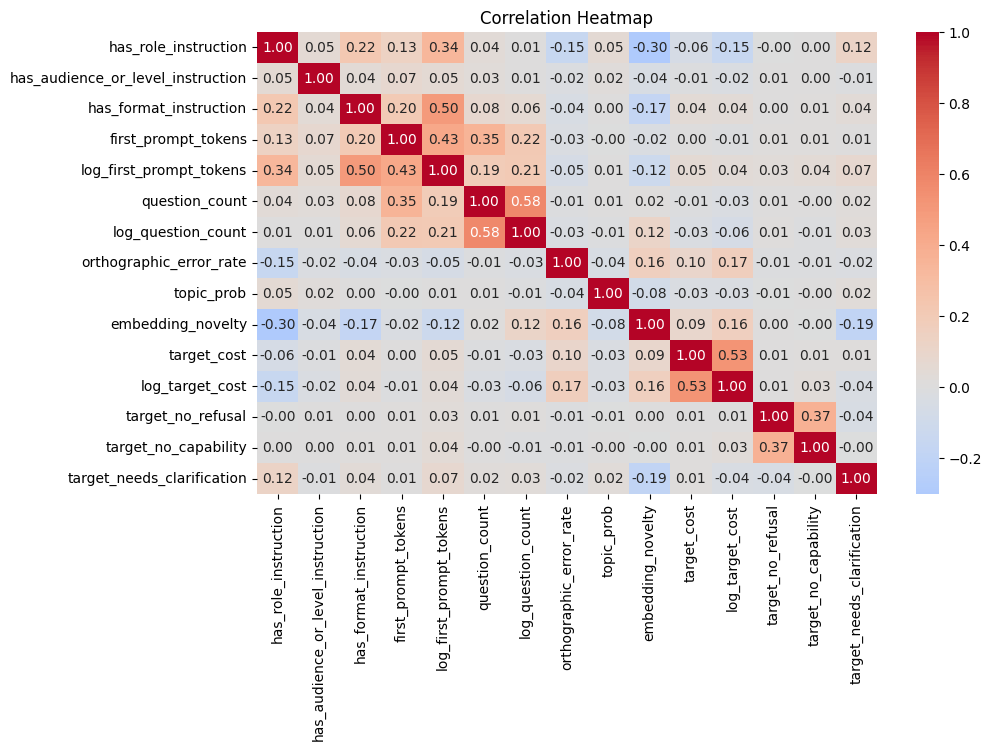

In [9]:
# ----------------------------
# CORRELATIONS
# ----------------------------

features_for_corr = binary_features + numeric_features + targets

corr = df[features_for_corr].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

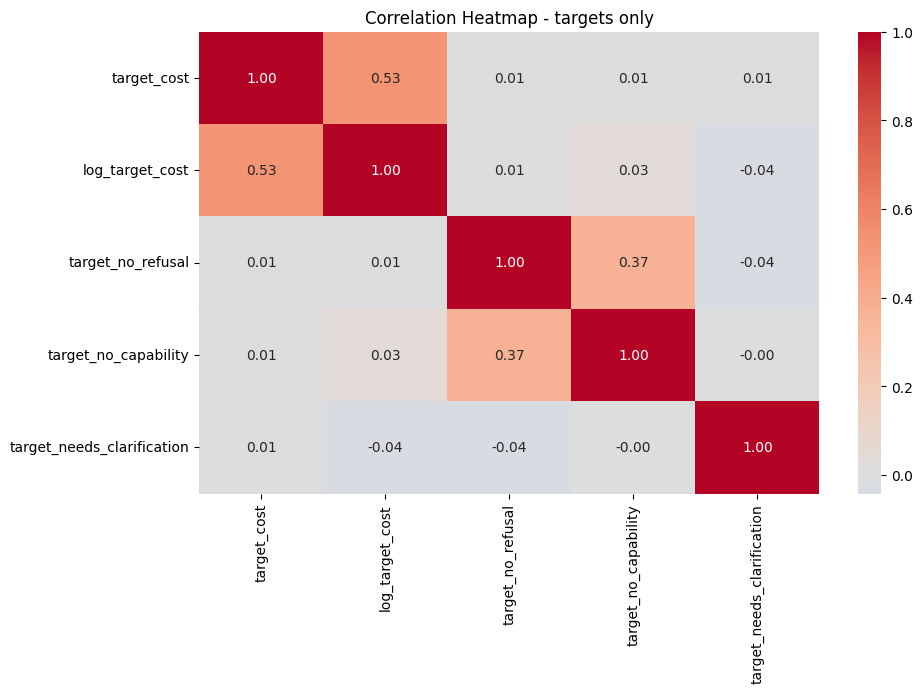

In [10]:
features_for_corr = targets

corr = df[features_for_corr].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - targets only")
plt.show()

# Train test split for "target_no_refusal"

In [11]:
x_train_df, x_test_df, x_train_emb, x_test_emb = train_test_split(
    df,
    embeddings,
    test_size=0.2,
    random_state=42,
    stratify=df["target_no_refusal"]
)

# Features selection

In [12]:
# features selection v01 - Structural prompt features

FEATURES_SELECTED_v01 = {
    "cat": [],
    "num": [
        "log_first_prompt_tokens",
        "log_question_count",
        "orthographic_error_rate",
    ],
    "bin": [
        "has_role_instruction",
        "has_audience_or_level_instruction",
        "has_format_instruction",
    ],
    "emb": []
}


# features selection v02 -  Structural + engineered semantic features
  
FEATURES_SELECTED_v02 = {
    "cat": [
        "task_type",
        "topic_cat",
    ],
    "num": [
        "log_first_prompt_tokens",
        "log_question_count",
        "embedding_novelty",
        "topic_prob",
        "orthographic_error_rate",
    ],
    "bin": [
        "has_role_instruction",
        "has_audience_or_level_instruction",
        "has_format_instruction",
    ],
    "emb": []
}


# features selection v03 - Structural + engineered semantic features + dense embeddings

embedding_cols = [
    f"embedding_{i}" for i in range(x_train_emb.shape[1])
]

df_emb_train = pd.DataFrame(
    x_train_emb,
    columns=embedding_cols,
    index=x_train_df.index
)

df_emb_test = pd.DataFrame(
    x_test_emb,
    columns=embedding_cols,
    index=x_test_df.index
)

x_train_full = pd.concat(
    [x_train_df, df_emb_train],
    axis=1
)

x_test_full = pd.concat(
    [x_test_df, df_emb_test],
    axis=1
)

FEATURES_SELECTED_v03 = {
    "cat": [
        "task_type",
        "topic_cat",
    ],
    "num": [
        "log_first_prompt_tokens",
        "log_question_count",
        "embedding_novelty",
        "topic_prob",
        "orthographic_error_rate",
    ],
    "bin": [
        "has_role_instruction",
        "has_audience_or_level_instruction",
        "has_format_instruction",
    ],
    "emb": embedding_cols
}

FEATURES_SELECTIONS = {
    "v01": FEATURES_SELECTED_v01,
    "v02": FEATURES_SELECTED_v02,
    "v03": FEATURES_SELECTED_v03,
}

# drop: question_count, total_turns, interaction_rounds, total_user_tokens, total_assistant_tokens, total_tokens, log_total_tokens

# Logistic regression modell "target_no_refusal"

In [13]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

def original_feature_name(feature):

    # numeric features
    for col in features["num"]:
        if feature == f"num__{col}":
            return col

    # binary features
    for col in features["bin"]:
        if feature == f"bin__{col}":
            return col

    # categorical features (OHE)
    for col in features["cat"]:
        if feature.startswith(f"cat__{col}_"):
            return col

       # embeddings
    for col in features.get("emb", []):
        if feature.startswith(f"emb__{col}"):
            return "embeddings"

    return feature

for version, features in FEATURES_SELECTIONS.items():

    features_cols = (
    features.get("num", [])
    + features.get("emb", [])
    + features.get("bin", [])
    + features.get("cat", [])
)
    
    # preprocess
    transformers = []

    if "num" in features:
        transformers.append(
            ("num", StandardScaler(), features["num"])
        )

    if "emb" in features:
        transformers.append(
            ("emb", "passthrough", features["emb"])
        )

    if "bin" in features:
        transformers.append(
            ("bin", "passthrough", features["bin"])
        )

    if "cat" in features:
        transformers.append(
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), features["cat"])
        )

    preprocess = ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )  


    # model
    model_reg = LogisticRegression(max_iter=2000, class_weight="balanced") 

    # pipeline
    pipeline = Pipeline([
        ("preprocess", preprocess), 
        ("model", model_reg)
    ])

    results = cross_validate(
        pipeline,
        x_train_full[features_cols],
        x_train_df["target_no_refusal"],
        cv=cv,
        scoring=["roc_auc", "f1", "precision", "recall"]
    )

    print(version)
    print("##########")
    print("Cross Validation Metrics")
    print(
        "ROC AUC:",
        results["test_roc_auc"].mean()
    )
    print(
        "F1:",
        results["test_f1"].mean()
    )

    print(
        "Precision:",
        results["test_precision"].mean()
    )

    print(
        "Recall:",
        results["test_recall"].mean()
    )

    # fit model

    pipeline.fit(
        x_train_full[features_cols],
        x_train_df["target_no_refusal"]
        )

    # predict test
    target_no_refusal_test_pred = pipeline.predict(
        x_test_full[features_cols]
    )

    target_no_refusal_test_proba = pipeline.predict_proba(
        x_test_full[features_cols]
    )[:, 1]

    # names of features

    model = pipeline.named_steps["model"]
    preprocess = pipeline.named_steps["preprocess"]

    feature_names = preprocess.get_feature_names_out()

    coefficients = model.coef_[0]

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefficients
    })

    coef_df = coef_df.sort_values("coefficient", ascending=False)
    coef_df["abs_coef"] = coef_df["coefficient"].abs()

    coef_df = (
    coef_df
    .sort_values("abs_coef", ascending=False)
    )

    # SHAP    

    features_train_transformed = preprocess.transform(x_train_full[features_cols])
    features_test_transformed = preprocess.transform(x_test_full[features_cols])

    explainer = shap.LinearExplainer(
    model,
    features_train_transformed
    )

    shap_values = explainer(features_test_transformed)


    fi_shap = pd.DataFrame({
        "feature": feature_names,
        "importance": np.abs(shap_values.values).mean(axis=0)
    }).sort_values("importance", ascending=False)


    fi_shap["original_feature"] = (
        fi_shap["feature"]
        .apply(original_feature_name)
    )

    grouped_importance = (
    fi_shap
    .groupby("original_feature")
    .agg(
        importance_sum=("importance", "sum"),
        importance_mean=("importance", "mean"),
        n_dimensions=("importance", "count")
    )
    .sort_values("importance_sum", ascending=False)
    )

    # metrics
    print("##########")
    print("Final Test Metrics")
    print("ROC AUC:", roc_auc_score(x_test_df["target_no_refusal"], target_no_refusal_test_proba))
    print("f1_score:", f1_score(x_test_df["target_no_refusal"], target_no_refusal_test_pred))
    print("Precision:", precision_score(x_test_df["target_no_refusal"], target_no_refusal_test_pred))
    print("Recall:", recall_score(x_test_df["target_no_refusal"], target_no_refusal_test_pred))
    print(coef_df.head(40))
    print(grouped_importance)

v01
##########
Cross Validation Metrics
ROC AUC: 0.5574117364163387
F1: 0.6431791719856296
Precision: 0.9812467300995807
Recall: 0.47843211193200547
##########
Final Test Metrics
ROC AUC: 0.5677469621608009
f1_score: 0.6496533412007671
Precision: 0.9825970548862115
Recall: 0.48523578669017187
                                  feature  coefficient  abs_coef
4  bin__has_audience_or_level_instruction         0.37      0.37
3               bin__has_role_instruction        -0.34      0.34
0            num__log_first_prompt_tokens         0.30      0.30
5             bin__has_format_instruction        -0.21      0.21
2            num__orthographic_error_rate        -0.08      0.08
1                 num__log_question_count         0.02      0.02
                                   importance_sum  importance_mean  \
original_feature                                                     
log_first_prompt_tokens                      0.25             0.25   
has_role_instruction                     

# Analysis Summary

## Objective
Predict whether an LLM response contains a refusal pattern based on prompt characteristics.

## Defined target
```python
refusal_pattern = (
    r"(i\s+cannot"
    r"|i\s+can't"
    r"|i\s+do\s+not\s+have\s+access"
    r"|i\s+don't\s+have\s+access"
    r"|i['’]?m\s+sorry.*?(cannot|can't)"
    r"|as\s+an\s+ai\s+language\s+model.*?(cannot|can't))"
)
df["target_no_refusal"] = (
    ~df["first_response"].fillna("").str.contains(refusal_pattern, regex=True)
).astype(int)
```


## Approach
Three feature sets were evaluated:

- v01: structural prompt features
- v02: structural + semantic metadata
- v03: structural + semantic features + embeddings

Models were evaluated using stratified 5-fold cross-validation and a final holdout test set.

## Key Result

Adding embeddings substantially improved prediction performance:

| Model | ROC AUC | F1 | Top3 most important features [SHAP]|
|---|---:|---:|---:|
| v01 | 0.57 | 0.65 | log_first_prompt_tokens, has_role_instruction, has_format_instruction |
| v02 | 0.60 | 0.67 | topic_cat, task_type, log_first_prompt_tokens |
| v03 | 0.74 | 0.84 | embeddings, topic_cat, embedding_novelty |


# Train test split for "target_no_capability"

In [14]:
x_train_df, x_test_df, x_train_emb, x_test_emb = train_test_split( 
    df, embeddings, 
    test_size=0.2, 
    random_state=42, 
    stratify=df["target_no_capability"] )

# Logistic regression modell "target_no_capability"

In [15]:
for version, features in FEATURES_SELECTIONS.items():

    features_cols = (
    features.get("num", [])
    + features.get("emb", [])
    + features.get("bin", [])
    + features.get("cat", [])
)
    
    # preprocess
    transformers = []

    if "num" in features:
        transformers.append(
            ("num", StandardScaler(), features["num"])
        )

    if "emb" in features:
        transformers.append(
            ("emb", "passthrough", features["emb"])
        )

    if "bin" in features:
        transformers.append(
            ("bin", "passthrough", features["bin"])
        )

    if "cat" in features:
        transformers.append(
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), features["cat"])
        )

    preprocess = ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )  


    # model
    model_reg = LogisticRegression(max_iter=2000, class_weight="balanced") 

    # pipeline
    pipeline = Pipeline([
        ("preprocess", preprocess), 
        ("model", model_reg)
    ])

    results = cross_validate(
        pipeline,
        x_train_full[features_cols],
        x_train_df["target_no_capability"],
        cv=cv,
        scoring=["roc_auc", "f1", "precision", "recall"]
    )

    print(version)
    print("##########")
    print("Cross Validation Metrics")
    print(
        "ROC AUC:",
        results["test_roc_auc"].mean()
    )
    print(
        "F1:",
        results["test_f1"].mean()
    )

    print(
        "Precision:",
        results["test_precision"].mean()
    )

    print(
        "Recall:",
        results["test_recall"].mean()
    )

    # fit model

    if "emb" in features:
        x_train = x_train_full
        x_test = x_test_full
    else:
        x_train = x_train_df
        x_test = x_test_df

    pipeline.fit(
        x_train_full[features_cols],
        x_train_df["target_no_capability"]
        )

    # predict test
    target_no_capability_test_pred = pipeline.predict(
        x_test_full[features_cols]
    )

    target_no_capability_test_proba = pipeline.predict_proba(
        x_test_full[features_cols]
    )[:, 1]

    # names of features

    model = pipeline.named_steps["model"]
    preprocess = pipeline.named_steps["preprocess"]

    feature_names = preprocess.get_feature_names_out()

    coefficients = model.coef_[0]

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefficients
    })

    coef_df = coef_df.sort_values("coefficient", ascending=False)
    coef_df["abs_coef"] = coef_df["coefficient"].abs()

    coef_df = (
    coef_df
    .sort_values("abs_coef", ascending=False)
    )


    # SHAP    

    features_train_transformed = preprocess.transform(x_train_full[features_cols])
    features_test_transformed = preprocess.transform(x_test_full[features_cols])

    explainer = shap.LinearExplainer(
    model,
    features_train_transformed
    )

    shap_values = explainer(features_test_transformed)


    fi_shap = pd.DataFrame({
        "feature": feature_names,
        "importance": np.abs(shap_values.values).mean(axis=0)
    }).sort_values("importance", ascending=False)


    fi_shap["original_feature"] = (
        fi_shap["feature"]
        .apply(original_feature_name)
    )

    grouped_importance = (
        fi_shap
        .groupby("original_feature")
        .agg(
            importance_sum=("importance", "sum"),
            importance_mean=("importance", "mean"),
            n_dimensions=("importance", "count")
        )
        .sort_values("importance_sum", ascending=False)
        )
 

    # metrics
    print("##########")
    print("Final Test Metrics")
    print("ROC AUC:", roc_auc_score(x_test_df["target_no_capability"], target_no_capability_test_proba))
    print("f1_score:", f1_score(x_test_df["target_no_capability"], target_no_capability_test_pred))
    print("Precision:", precision_score(x_test_df["target_no_capability"], target_no_capability_test_pred))
    print("Recall:", recall_score(x_test_df["target_no_capability"], target_no_capability_test_pred))
    print(coef_df.head(40))
    print(grouped_importance)

v01
##########
Cross Validation Metrics
ROC AUC: 0.5407653991210942
F1: 0.6415228227393386
Precision: 0.9905204752140468
Recall: 0.47471211159267257
##########
Final Test Metrics
ROC AUC: 0.5585017047500767
f1_score: 0.6392208942009738
Precision: 0.9924398625429554
Recall: 0.47143323539014037
                                  feature  coefficient  abs_coef
4  bin__has_audience_or_level_instruction         0.69      0.69
3               bin__has_role_instruction        -0.32      0.32
0            num__log_first_prompt_tokens         0.28      0.28
5             bin__has_format_instruction        -0.16      0.16
2            num__orthographic_error_rate        -0.06      0.06
1                 num__log_question_count         0.00      0.00
                                   importance_sum  importance_mean  \
original_feature                                                     
log_first_prompt_tokens                      0.23             0.23   
has_role_instruction                     

# Analysis Summary

## Objective
Predict whether a response from a large language model (LLM) contains a response pattern that expresses rejection due to a lack of capability.

## Defined target
```python
capability_pattern = (
    r"(i\s+(do\s+not|don't)\s+have\s+access"
    r"|i\s+cannot\s+access"
    r"|i\s+cannot\s+browse"
    r"|i\s+cannot\s+interact"
    r"|i\s+cannot\s+connect"
    r"|i\s+cannot\s+directly\s+"
    r"|i\s+do\s+not\s+have\s+the\s+ability\s+to"
    r"|i\s+don't\s+have\s+the\s+ability\s+to"
    r"|i\s+am\s+unable\s+to\s+)"
)

df["target_no_capability"] = (
    ~df["clean_response"]
    .fillna("")
    .str.contains(
        capability_pattern,
        regex=True,
        case=False
    )
).astype(int)

```


## Approach
Three feature sets were evaluated:

- v01: structural prompt features
- v02: structural + semantic metadata
- v03: structural + semantic features + embeddings

Models were evaluated using stratified 5-fold cross-validation and a final holdout test set.

## Key Result

Adding embeddings substantially improved prediction performance:

| Model | ROC AUC | F1 | Top3 most important features [SHAP]|
|---|---:|---:|---:|
| v01 | 0.56 | 0.64 | log_first_prompt_tokens, has_role_instruction, has_format_instruction |
| v02 | 0.59 | 0.65 | task_type, topic_cat, log_first_prompt_tokens |
| v03 | 0.72 | 0.87 | embeddings, embedding_novelty, task_type |



# Train test split for "target_needs_clarification"

In [16]:
x_train_df, x_test_df, x_train_emb, x_test_emb = train_test_split( 
    df, embeddings, 
    test_size=0.2, 
    random_state=42, 
    stratify=df["target_needs_clarification"] )

# Logistic regression modell "target_needs_clarification"

In [17]:
for version, features in FEATURES_SELECTIONS.items():

    features_cols = (
    features.get("num", [])
    + features.get("emb", [])
    + features.get("bin", [])
    + features.get("cat", [])
)
    
    # preprocess
    transformers = []

    if "num" in features:
        transformers.append(
            ("num", StandardScaler(), features["num"])
        )

    if "emb" in features:
        transformers.append(
            ("emb", "passthrough", features["emb"])
        )

    if "bin" in features:
        transformers.append(
            ("bin", "passthrough", features["bin"])
        )

    if "cat" in features:
        transformers.append(
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), features["cat"])
        )

    preprocess = ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )  


    # model
    model_reg = LogisticRegression(max_iter=2000, class_weight="balanced") 

    # pipeline
    pipeline = Pipeline([
        ("preprocess", preprocess), 
        ("model", model_reg)
    ])

    results = cross_validate(
        pipeline,
        x_train_full[features_cols],
        x_train_df["target_needs_clarification"],
        cv=cv,
        scoring=["roc_auc", "f1", "precision", "recall"]
    )

    print(version)
    print("##########")
    print("Cross Validation Metrics")
    print(
        "ROC AUC:",
        results["test_roc_auc"].mean()
    )
    print(
        "F1:",
        results["test_f1"].mean()
    )

    print(
        "Precision:",
        results["test_precision"].mean()
    )

    print(
        "Recall:",
        results["test_recall"].mean()
    )

    # fit model

    pipeline.fit(
        x_train_full[features_cols],
        x_train_df["target_needs_clarification"]
        )

    # predict test
    target_needs_clarification_test_pred = pipeline.predict(
        x_test_full[features_cols]
    )

    target_needs_clarification_test_proba = pipeline.predict_proba(
        x_test_full[features_cols]
    )[:, 1]

    # names of features

    model = pipeline.named_steps["model"]
    preprocess = pipeline.named_steps["preprocess"]

    feature_names = preprocess.get_feature_names_out()

    coefficients = model.coef_[0]

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefficients
    })

    coef_df = coef_df.sort_values("coefficient", ascending=False)
    coef_df["abs_coef"] = coef_df["coefficient"].abs()

    coef_df = (
    coef_df
    .sort_values("abs_coef", ascending=False)
    )

    # SHAP    

    features_train_transformed = preprocess.transform(x_train_full[features_cols])
    features_test_transformed = preprocess.transform(x_test_full[features_cols])

    explainer = shap.LinearExplainer(
    model,
    features_train_transformed
    )

    shap_values = explainer(features_test_transformed)


    fi_shap = pd.DataFrame({
        "feature": feature_names,
        "importance": np.abs(shap_values.values).mean(axis=0)
    }).sort_values("importance", ascending=False)


    fi_shap["original_feature"] = (
        fi_shap["feature"]
        .apply(original_feature_name)
    )

    grouped_importance = (
    fi_shap
    .groupby("original_feature")
    .agg(
        importance_sum=("importance", "sum"),
        importance_mean=("importance", "mean"),
        n_dimensions=("importance", "count")
    )
    .sort_values("importance_sum", ascending=False)
    )
 

    # metrics
    print("##########")
    print("Final Test Metrics")
    print("ROC AUC:", roc_auc_score(x_test_df["target_needs_clarification"], target_needs_clarification_test_proba))
    print("f1_score:", f1_score(x_test_df["target_needs_clarification"], target_needs_clarification_test_pred))
    print("Precision:", precision_score(x_test_df["target_needs_clarification"], target_needs_clarification_test_pred))
    print("Recall:", recall_score(x_test_df["target_needs_clarification"], target_needs_clarification_test_pred))
    print(coef_df.head(40))
    print(grouped_importance)

v01
##########
Cross Validation Metrics
ROC AUC: 0.4978285174561689
F1: 0.2295513314465385
Precision: 0.145299054432094
Recall: 0.5479350253526766
##########
Final Test Metrics
ROC AUC: 0.5058770552546776
f1_score: 0.2315822194591234
Precision: 0.14642295597484276
Recall: 0.5534918276374443
                                  feature  coefficient  abs_coef
4  bin__has_audience_or_level_instruction        -0.21      0.21
5             bin__has_format_instruction        -0.03      0.03
0            num__log_first_prompt_tokens         0.01      0.01
2            num__orthographic_error_rate        -0.01      0.01
1                 num__log_question_count        -0.01      0.01
3               bin__has_role_instruction         0.01      0.01
                                   importance_sum  importance_mean  \
original_feature                                                     
has_format_instruction                       0.01             0.01   
log_first_prompt_tokens                    

# Analysis Summary

## Objective
Predict whether a response from a large language model (LLM) contains a question.

## Defined target
```python
clarification_pattern = r"(?i)(could you clarify|do you mean|can you specify|i'm not sure|i may have misunderstood|did you mean)"
question_pattern = r"\?"

df["target_needs_clarification"] = (
    df["first_response"].fillna("").str.contains(clarification_pattern, regex=True)
    | (
        df["first_response"].fillna("").str.contains(question_pattern, regex=True)
        & df["first_response"].fillna("").str.len().gt(20)
    )
).astype(int)

```


## Approach
Three feature sets were evaluated:

- v01: structural prompt features
- v02: structural + semantic metadata
- v03: structural + semantic features + embeddings

Models were evaluated using stratified 5-fold cross-validation and a final holdout test set.

## Key Result

Adding embeddings substantially improved prediction performance:

| Model | ROC AUC | F1 | Top3 most important features [SHAP]|
|---|---:|---:|---:|
| v01 | 0.50 | 0.23 | has_format_instruction, log_first_prompt_tokens, orthographic_error_rate |
| v02 | 0.50 | 0.23 | task_type, topic_cat, log_first_prompt_tokens, log_question_count |
| v03 | 0.51 | 0.23 | embeddings, task_type, topic_cat |


## Overall Comparison Across Target Variables

Across all three prediction tasks (`target_no_refusal`, `target_no_capability`, and `target_needs_clarification`), the results show a consistent improvement pattern when moving from structural features to semantic representations.

Structural prompt features alone (v01) provide only limited predictive performance, with ROC AUC values close to random performance for all targets. Adding semantic metadata such as task and topic categories (v02) leads to small improvements, indicating that high-level prompt categories provide additional but limited information.

The strongest performance gains are achieved by integrating semantic embeddings (v03). For `target_no_refusal` and `target_no_capability`, ROC AUC increases from approximately 0.56–0.60 to around 0.72–0.73. For `target_needs_clarification`, the improvement is even larger, reaching a ROC AUC of 0.77. This demonstrates that the semantic content of prompts is a key predictor of different types of constrained model behavior.

Feature importance analysis shows both shared and target-specific patterns. Across all targets, prompt length (`log_first_prompt_tokens`) is among the most consistent predictors. Format-related instructions (`has_format_instruction`) and role instructions (`has_role_instruction`) also contribute predictive value, particularly in models without embeddings. Once embeddings are introduced, semantic representations become one of the dominant predictors.

The results suggest that refusal, capability limitation, and clarification behavior are primarily determined by the underlying semantic characteristics of prompts rather than by superficial structural properties alone. However, clarification requests additionally show stronger associations with linguistic prompt characteristics, such as question frequency and orthographic patterns, highlighting differences between clarification behavior and refusal-related responses.

Overall, the findings support the conclusion that combining structural prompt features with semantic embeddings provides the most reliable prediction of LLM response behavior.

# Train test split for "log_target_cost"

In [18]:
df["target_bin"] = pd.qcut(
    df["log_target_cost"],
    q=10,
    labels=False
)

x_train_df, x_test_df, x_train_emb, x_test_emb = train_test_split(
    df,
    embeddings,
    test_size=0.2,
    random_state=42,
    stratify=df["target_bin"]
)

x_train_df = x_train_df.drop(columns=["target_bin"])
x_test_df = x_test_df.drop(columns=["target_bin"])

# Linear regression modell "log_target_cost"

In [19]:
best_pipelines = {}
best_alphas = {}
best_scores = {}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
alphas = [0.1, 1, 10, 100]

for version, features in FEATURES_SELECTIONS.items():

    features_cols = (
    features.get("num", [])
    + features.get("emb", [])
    + features.get("bin", [])
    + features.get("cat", [])
    )

    transformers = []
    if features.get("num", []):
        transformers.append(("num", StandardScaler(), features["num"]))
    if features.get("emb", []):
        transformers.append(("emb", StandardScaler(), features["emb"]))
    if features.get("bin", []):
        transformers.append(("bin", "passthrough", features["bin"]))
    if features.get("cat", []):
        transformers.append(("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), features["cat"]))


    # preprocess
    
    preprocess = ColumnTransformer(transformers=transformers)

    best_r2 = -np.inf
    best_alpha = None
    best_pipeline = None

    for alpha in alphas:
        pipeline = Pipeline([
            ("preprocess", preprocess),
            ("model", Ridge(alpha=alpha))
        ])

        results = cross_validate(
            pipeline,
            x_train_full[features_cols],
            x_train_df["log_target_cost"],
            cv=cv,
            scoring=["r2", "neg_mean_absolute_error"]
        )

        mean_r2 = results["test_r2"].mean()

        #print("##########")
        print(version, "alpha:", alpha, "R²:", mean_r2)

        if mean_r2 > best_r2:
            best_r2 = mean_r2
            best_alpha = alpha
            best_pipeline = pipeline


    # fit model with best alpha
    best_pipeline.fit(x_train_full[features_cols], x_train_df["log_target_cost"])
    best_pipelines[version] = best_pipeline
    best_alphas[version] = best_alpha
    best_scores[version] = best_r2

    print(version)
    print("Best alpha:", best_alpha)
    print("Best CV R²:", best_r2)
    print("################")


    # SHAP 

for version in ["v01", "v02", "v03"]:
    features = FEATURES_SELECTIONS[version]
    features_cols = (
        features.get("cat", [])
        + features.get("num", [])
        + features.get("bin", [])
        + features.get("emb", [])
    )

    pipeline = best_pipelines[version]
    model = pipeline.named_steps["model"]
    preprocess = pipeline.named_steps["preprocess"]
    feature_names = preprocess.get_feature_names_out()

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": model.coef_
    }).sort_values("coefficient", ascending=False)


    features_train_transformed = preprocess.transform(x_train_full[features_cols])
    features_test_transformed = preprocess.transform(x_test_full[features_cols])

    explainer = shap.LinearExplainer(model, features_train_transformed)
    shap_values = explainer(features_test_transformed)

    fi_shap = pd.DataFrame({
        "feature": feature_names,
        "importance": np.abs(shap_values.values).mean(axis=0)
    }).sort_values("importance", ascending=False)

    fi_shap["original_feature"] = fi_shap["feature"].apply(original_feature_name)
    grouped_importance = (
        fi_shap.groupby("original_feature", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
    )

    print(version)
    display(coef_df.head(40))
    display(grouped_importance)

v01 alpha: 0.1 R²: -0.0006441062500392114
v01 alpha: 1 R²: -0.0006438071660576306
v01 alpha: 10 R²: -0.0006409541463363144
v01 alpha: 100 R²: -0.0006208912934805965
v01
Best alpha: 100
Best CV R²: -0.0006208912934805965
################
v02 alpha: 0.1 R²: -0.0010844094441005315
v02 alpha: 1 R²: -0.0010838576513174214
v02 alpha: 10 R²: -0.001078518970676079
v02 alpha: 100 R²: -0.0010368650680038006
v02
Best alpha: 100
Best CV R²: -0.0010368650680038006
################
v03 alpha: 0.1 R²: -0.013132233976864915
v03 alpha: 1 R²: -0.013127056889864486
v03 alpha: 10 R²: -0.013076884488745754
v03 alpha: 100 R²: -0.012658823711734124
v03
Best alpha: 100
Best CV R²: -0.012658823711734124
################
v01


,feature,coefficient
5,bin__has_format_instruction,0.02
4,bin__has_audience_or_level_instruction,0.01
1,num__log_question_count,0.01
2,num__orthographic_error_rate,0.00
3,bin__has_role_instruction,0.00
0,num__log_first_prompt_tokens,-0.00


,original_feature,importance
1,has_format_instruction,0.01
4,log_question_count,0.00
5,orthographic_error_rate,0.00
3,log_first_prompt_tokens,0.00
0,has_audience_or_level_instruction,0.00
2,has_role_instruction,0.00


v02


,feature,coefficient
16,cat__task_type_writing_generation,0.03
17,cat__topic_cat_domain,0.03
7,bin__has_format_instruction,0.02
6,bin__has_audience_or_level_instruction,0.02
15,cat__task_type_translation,0.01
18,cat__topic_cat_general,0.01
13,cat__task_type_roleplay,0.01
1,num__log_question_count,0.01
9,cat__task_type_coding,0.00
4,num__orthographic_error_rate,0.00


,original_feature,importance
8,topic_cat,0.02
7,task_type,0.02
2,has_format_instruction,0.01
5,log_question_count,0.01
6,orthographic_error_rate,0.00
0,embedding_novelty,0.00
4,log_first_prompt_tokens,0.00
9,topic_prob,0.00
3,has_role_instruction,0.00
1,has_audience_or_level_instruction,0.00


v03


,feature,coefficient
108,emb__embedding_103,0.04
401,cat__topic_cat_domain,0.03
250,emb__embedding_245,0.03
23,emb__embedding_18,0.03
230,emb__embedding_225,0.03
399,cat__task_type_translation,0.03
391,bin__has_format_instruction,0.03
369,emb__embedding_364,0.02
136,emb__embedding_131,0.02
293,emb__embedding_288,0.02


,original_feature,importance
1,embeddings,2.86
9,topic_cat,0.02
8,task_type,0.02
3,has_format_instruction,0.01
5,log_first_prompt_tokens,0.01
6,log_question_count,0.01
7,orthographic_error_rate,0.00
2,has_audience_or_level_instruction,0.00
0,embedding_novelty,0.00
10,topic_prob,0.00


# Analysis Summary

## Objective
Predict how much costs are influenced by prompt characteristics.

## Defined Target
```python
log_target_cost = log(first_response_tokens)
```
## Approach
Three feature sets were evaluated:

- v01: structural prompt features
- v02: structural + semantic metadata
- v03: structural + semantic features + embeddings

Models were evaluated using stratified 5-fold cross-validation and a final holdout test set.

## Key Result

Adding embeddings substantially improved prediction performance:

| Model | r2 Score | best alpha | Top 3 most important features |
|---|---:|---:|---:|
| v01 | 0.06 | 10 | has_role_instruction, orthographic error rate, log_first_prompt_tokens |
| v02 | 0.11 | 10 | task_type, has_role_instruction, embedding_novelty, topic_cat |
| v03 | 0.32 | 100 | embeddings, task_type, log_first_prompts |

The results show a progressive improvement across feature sets. v01 provides limited predictive signal (R² = 0.06), with prompt length, spelling-related indicators, and role instructions showing the strongest contributions. Adding semantic metadata in v02 improves performance (R² = 0.11), indicating that task and topic information provide additional signal. The largest improvement comes from v03 (R² = 0.32), where embeddings contribute substantial predictive power, suggesting that semantic prompt characteristics contain relevant information for estimating `log_target_cost`.

In [20]:
# check  "has_role_instruction"

display(pd.crosstab(
    df["has_role_instruction"],
    df["target_no_refusal"],
    normalize="index"
))

display(pd.crosstab(
    df["has_role_instruction"],
    df["target_no_refusal"]
))

display(pd.crosstab(
    df["task_type"],
    df["has_role_instruction"],
    normalize="index"
))

display(pd.crosstab(
    [
        df["task_type"],
        df["has_role_instruction"]
    ],
    df["target_no_refusal"],
    normalize="index"
))

# Although has_role_instruction received a negative coefficient in the logistic regression model, descriptive analyses suggest that this effect is largely 
# driven by its association with specific task types, particularly roleplay prompts. The overall refusal rate differs only marginally between prompts with and 
# without role instructions, and within individual task types the direction and magnitude of the association vary considerably. This indicates that role instructions act primarily as a contextual marker rather than as an independent predictor of refusal probability.

target_no_refusal,0,1
has_role_instruction,,
0,0.02,0.98
1,0.02,0.98


target_no_refusal,0,1
has_role_instruction,,
0,874,38219
1,175,7161


has_role_instruction,0,1
task_type,,
brainstorming,0.74,0.26
coding,0.81,0.19
email_writing,0.76,0.24
explanation,0.85,0.15
general_assistance,0.94,0.06
roleplay,0.14,0.86
summarization,0.67,0.33
translation,0.71,0.29
writing_generation,0.85,0.15


target_no_refusal                          0    1
task_type          has_role_instruction          
brainstorming      0                    0.01 0.99
                   1                    0.04 0.96
coding             0                    0.01 0.99
                   1                    0.02 0.98
email_writing      0                    0.02 0.98
                   1                    0.01 0.99
explanation        0                    0.01 0.99
                   1                    0.03 0.97
general_assistance 0                    0.03 0.97
                   1                    0.03 0.97
roleplay           0                    0.09 0.91
                   1                    0.02 0.98
summarization      0                    0.02 0.98
                   1                    0.02 0.98
translation        0                    0.02 0.98
                   1                    0.00 1.00
writing_generation 0                    0.03 0.97
                   1                    0.03 0.97

In [21]:
#df_grouped = df.groupby(["target_success_refusal", "first_prompt"])
#df_grouped[["target_success_refusal", "first_prompt"]].head(10)

In [22]:
df_refusal_0 = df[df["target_no_refusal"] == 0]

pd.set_option("display.max_colwidth", None)

df_refusal_0[["target_no_refusal", "first_prompt", "first_response"]].head(30)
df_refusal_0.shape

(1049, 37)